# Comment Score Analysis

This notebook analyzes score distributions and text evaluation fields from `comment_scores.csv` and `comment_scores.jsonl`.

It supports multiple source labels — including `human`, `ai`, `statt`, `gemini`, or any other label produced by the evaluator — and breaks down results both by **source** and by **policy** (e.g. EPA, FDA, FMCSA).

In [1]:
# Install dependencies (run once)
#%pip install -q pandas matplotlib seaborn bertopic sentence-transformers umap-learn hdbscan scikit-learn

In [2]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP

BASE_DIR = Path.cwd()
ANALYSIS_DIR = BASE_DIR
CSV_PATH = ANALYSIS_DIR / "comment_scores.csv"
JSONL_PATH = ANALYSIS_DIR / "comment_scores.jsonl"

## Load Data

Use the CSV for tabular analysis and the JSONL for raw text fields if needed.
A `display_name` column is present for CSV-sourced comments (Statt / Gemini).

In [3]:
df = pd.read_csv(CSV_PATH)

# Normalise label capitalisation so 'Statt' and 'statt' merge
df["source_label"] = df["source_label"].fillna("unknown").str.lower().str.strip()

# Exclude unknown labels from analysis
df = df[df["source_label"] != "unknown"].copy()

POLICY_ID_PATTERNS = [
    r"\bEPA-[A-Z]{2}-[A-Z]{2}-\d{4}-\d{4}\b",
    r"\bFDA-\d{4}-[A-Z]-\d{4}\b",
    r"\bFMCSA-\d{4}-\d{4}\b",
    r"\b[A-Z]{3,}-\d{4}-[A-Z]-\d{3,5}\b",
    r"\b[A-Z]{3,}-\d{4}-\d{3,6}\b",
]

def _text_candidates(row):
    candidates = []
    comment_text = row.get("comment_text")
    file_value = row.get("file")
    if isinstance(comment_text, str) and comment_text.strip():
        candidates.append(comment_text)
    if isinstance(file_value, str) and file_value.strip():
        candidates.append(file_value)
    return candidates

def _extract_policy_id_from_text(text):
    for pattern in POLICY_ID_PATTERNS:
        match = re.search(pattern, text)
        if match:
            return match.group(0)
    return "unknown"

def _extract_policy_id_from_payload(payload):
    for key in ["docketId", "docket_id", "docketID", "docket", "policy_id", "policyId"]:
        value = payload.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    comment_text = payload.get("comment_text") or payload.get("comment") or payload.get("text")
    if isinstance(comment_text, str) and comment_text.strip():
        return _extract_policy_id_from_text(comment_text)
    return "unknown"

_policy_cache = {}

def infer_policy_id(row) -> str:
    policy_id = str(row.get("policy_id", "")).strip()
    if policy_id and policy_id.lower() != "unknown":
        return policy_id
    if row.get("source_label") == "human":
        for text in _text_candidates(row):
            inferred = _extract_policy_id_from_text(text)
            if inferred != "unknown":
                return inferred
        file_value = row.get("file")
        if isinstance(file_value, str) and file_value.strip():
            if file_value in _policy_cache:
                return _policy_cache[file_value]
            path = Path(file_value)
            if path.exists() and path.suffix == ".json":
                try:
                    payload = json.loads(path.read_text(encoding="utf-8"))
                    inferred = _extract_policy_id_from_payload(payload)
                except Exception:
                    inferred = "unknown"
                _policy_cache[file_value] = inferred
                return inferred
    return "unknown"

def infer_policy_agency(row) -> str:
    policy_id = str(row.get("policy_id", "")).strip()
    if policy_id and policy_id.lower() != "unknown":
        return policy_id.split("-")[0].upper()
    if row.get("source_label") == "human":
        for text in _text_candidates(row):
            match = re.search(r"\b(EPA|FDA|FMCSA)\b", text, flags=re.IGNORECASE)
            if match:
                return match.group(1).upper()
    return "unknown"

# Refresh policy_id for humans using the evaluator's docket patterns
df["policy_id"] = df.apply(infer_policy_id, axis=1)

# Add an agency-only policy label (e.g. EPA/FDA) for higher-level summaries
df["policy_agency"] = df.apply(infer_policy_agency, axis=1)

# Ensure display_name column exists (older score files may not have it)
if "display_name" not in df.columns:
    df["display_name"] = ""

def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            continue
    return rows

raw_rows = load_jsonl(JSONL_PATH)

score_cols    = [c for c in df.columns if c.startswith("score_")]
rationale_cols = [c for c in df.columns if c.startswith("rationale_")]
labels         = sorted(df["source_label"].unique().tolist())
policies       = sorted(df["policy_id"].fillna("unknown").unique().tolist())
SOURCE_PALETTE = {
    "human": "#4C78A8",
    "gemini": "#F58518",
    "statt": "#54A24B",
}

print(f"Rows: {len(df)}  |  Sources: {labels}  |  Policies: {policies}")
len(df), len(raw_rows)

Rows: 3928  |  Sources: ['gemini', 'human', 'statt']  |  Policies: ['CMS-2023-0144', 'CRRMS-2024-0040', 'EPA', 'EPA-HQ-OA-2013-0320', 'EPA-HQ-OW-2022-0801', 'EPA-HQ-OW-2023-0469', 'EPA-HQ-OW-2023-0475', 'EPA-HQ-OW-2024-0481', 'EPA-HQ-OW-2025-2929', 'FDA', 'FDA-2023-N-2177', 'FDA-2024-C-1085', 'FDA-2024-D-2581', 'FDA-2024-N-0021', 'FDA-2024-N-3924', 'FDA-2024-N-4815', 'FMCSA', 'FMCSA-2023-0257', 'FMCSA-2025-0124', 'FSIS-2024-0021', 'OAR-2002-0083', 'OAR-2023-0151', 'OAR-2023-0282', 'OAR-2023-0402', 'OAR-2023-0614', 'OAR-2024-0186', 'OAR-2024-0303', 'OAR-2024-0411', 'OAR-2024-0453', 'OAR-2024-0459', 'OAR-2024-0622', 'OAR-2025-0194', 'OPPT-2023-0613', 'SBA-2024-0003', 'USTR-2024-0015']


(3928, 3934)

## Quick Overview

Check label counts, policy counts, and missing values.

In [4]:
print("=== Source label counts ===")
display(df["source_label"].value_counts(dropna=False).rename("count").to_frame())

print("\n=== Policy ID counts ===")
display(df["policy_id"].fillna("unknown").value_counts(dropna=False).rename("count").to_frame())

print("\n=== Comments per policy × source ===")
display(pd.crosstab(df["policy_id"].fillna("unknown"), df["source_label"]))

print("\n=== Missing values (top 10) ===")
display(df.isna().sum().sort_values(ascending=False).head(10))

=== Source label counts ===


,count
source_label,
human,3295
statt,317
gemini,316



=== Policy ID counts ===


,count
policy_id,
FMCSA-2023-0257,1099
FDA-2024-C-1085,1098
EPA-HQ-OW-2025-2929,1098
FDA,193
EPA,129
FMCSA,123
FMCSA-2025-0124,91
OAR-2025-0194,68
OAR-2023-0614,2



=== Comments per policy × source ===


source_label,gemini,human,statt
policy_id,,,
CMS-2023-0144,0,0,1
CRRMS-2024-0040,0,0,1
EPA,108,0,21
EPA-HQ-OA-2013-0320,0,0,1
EPA-HQ-OW-2022-0801,0,0,1
EPA-HQ-OW-2023-0469,0,0,1
EPA-HQ-OW-2023-0475,0,0,1
EPA-HQ-OW-2024-0481,0,0,1
EPA-HQ-OW-2025-2929,0,1098,0



=== Missing values (top 10) ===


error                             3928
display_name                       223
file                                 0
score_structure_formatting           0
rationale_overall                    0
rationale_structure_formatting       0
rationale_actionability              0
rationale_impact                     0
rationale_evidence                   0
rationale_reasoning                  0
dtype: int64

## Agency-Level Policy Summary

Aggregate policy labels to their agency prefix (e.g., EPA/FDA) for a higher-level view.

=== Agency counts ===


,count
policy_agency,
FMCSA,1313
FDA,1296
EPA,1232
OAR,81
OPPT,1
SBA,1
FSIS,1
CMS,1
USTR,1



=== Comments per agency × source ===


source_label,gemini,human,statt
policy_agency,,,
CMS,0,0,1
CRRMS,0,0,1
EPA,108,1098,26
FDA,101,1098,97
FMCSA,107,1099,107
FSIS,0,0,1
OAR,0,0,81
OPPT,0,0,1
SBA,0,0,1


source_label,gemini,human,statt
policy_agency,,,
CMS,NaN,NaN,3.00
CRRMS,NaN,NaN,4.00
EPA,2.68,2.11,4.23
FDA,2.09,2.76,4.01
FMCSA,2.27,2.08,4.27
FSIS,NaN,NaN,4.00
OAR,NaN,NaN,4.26
OPPT,NaN,NaN,4.00
SBA,NaN,NaN,5.00


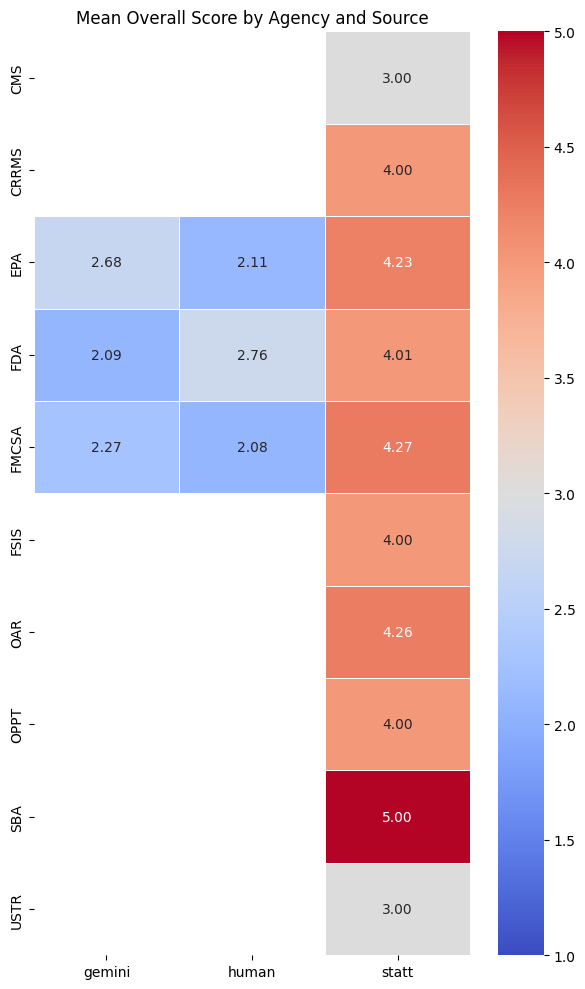

In [5]:
print("=== Agency counts ===")
display(df["policy_agency"].value_counts(dropna=False).rename("count").to_frame())

print("\n=== Comments per agency × source ===")
display(pd.crosstab(df["policy_agency"], df["source_label"]))

if "score_overall" in df.columns:
    agency_by_source = df.pivot_table(
        values="score_overall",
        index="policy_agency",
        columns="source_label",
        aggfunc="mean",
    ).round(2)
    display(agency_by_source)

    fig, ax = plt.subplots(
        figsize=(max(6, len(labels) * 1.5), max(3, len(agency_by_source)))
    )
    sns.heatmap(
        agency_by_source, annot=True, fmt=".2f", cmap="coolwarm",
        vmin=1, vmax=5, linewidths=0.5, ax=ax,
    )
    ax.set_title("Mean Overall Score by Agency and Source")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Score Distributions

Per-criterion score distributions coloured by source label.

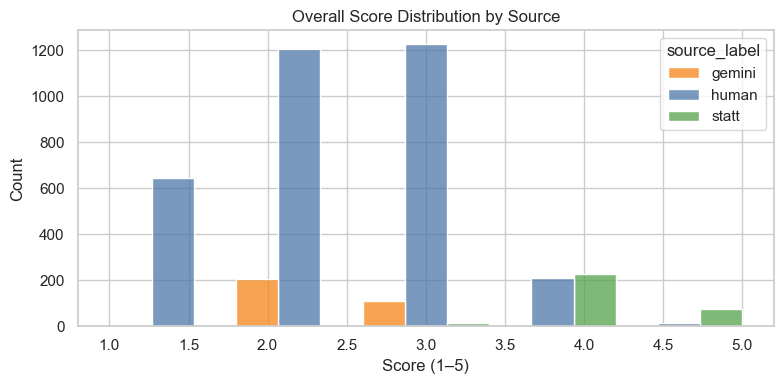

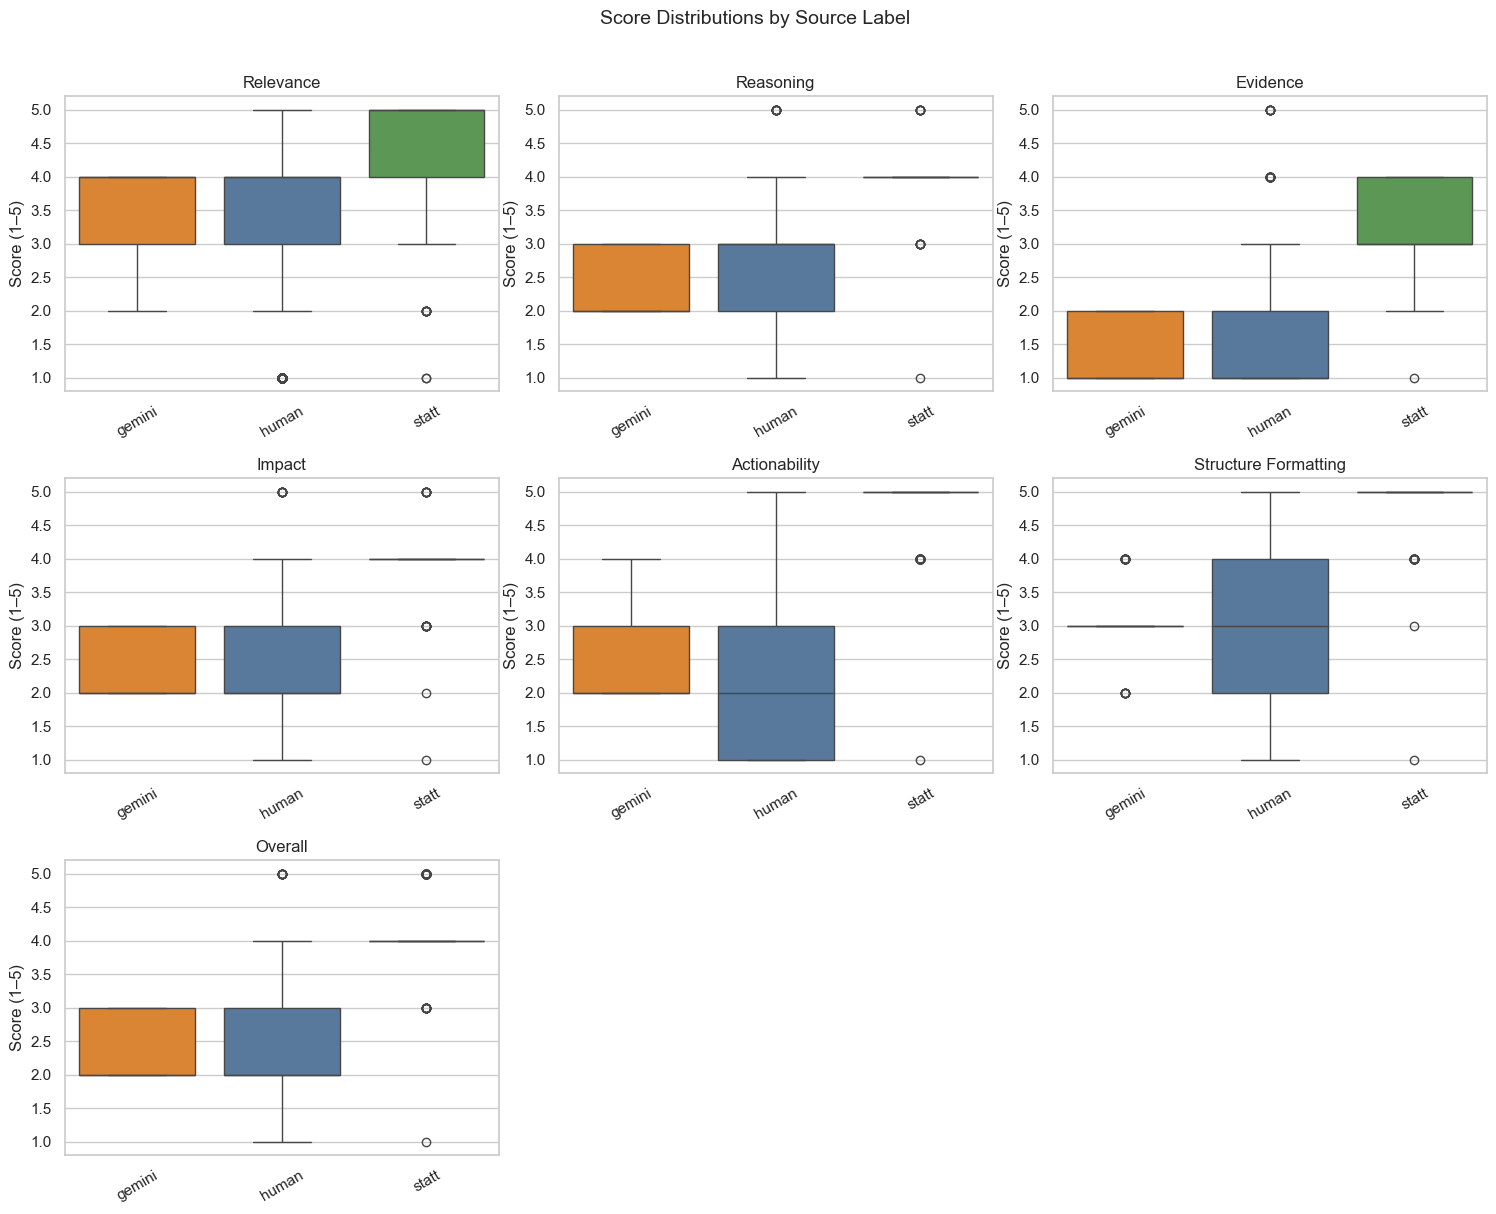

In [6]:
sns.set_theme(style="whitegrid")

# ── Overall score histogram ──────────────────────────────────────────────
if "score_overall" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(
        data=df, x="score_overall", hue="source_label",
        hue_order=labels, palette=SOURCE_PALETTE,
        multiple="dodge", bins=5, ax=ax,
    )
    ax.set_title("Overall Score Distribution by Source")
    ax.set_xlabel("Score (1–5)")
    plt.tight_layout()
    plt.show()

# ── Box plots: all criteria by source label ──────────────────────────────
n_cols = 3
n_rows = -(-len(score_cols) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    sns.boxplot(
        data=df, x="source_label", y=col,
        order=labels, ax=axes[i], palette=SOURCE_PALETTE,
    )
    axes[i].set_title(col.replace("score_", "").replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Score (1–5)")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Score Distributions by Source Label", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Mean Scores by Source

Average score per criterion, broken down by source label.

,score_relevance,score_reasoning,score_evidence,score_impact,score_actionability,score_structure_formatting,score_overall
source_label,,,,,,,
gemini,3.55,2.40,1.30,2.29,2.52,3.07,2.35
human,3.28,2.54,1.35,2.28,2.28,2.80,2.31
statt,4.54,3.99,3.30,3.97,4.82,4.89,4.18


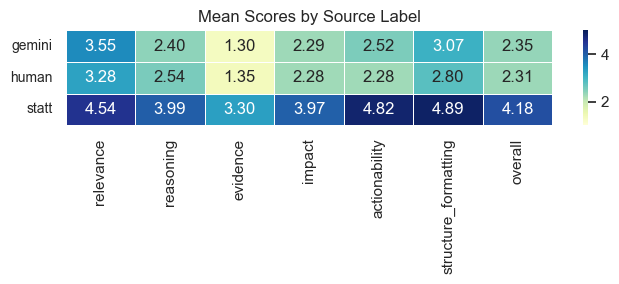

In [7]:
summary_by_source = df.groupby("source_label")[score_cols].mean().round(2)
display(summary_by_source)

# Heatmap
asfig, ax = plt.subplots(
    figsize=(max(6, len(score_cols)), max(3, len(labels) * 0.7))
)
sns.heatmap(
    summary_by_source,
    annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=1, vmax=5, linewidths=0.5, ax=ax,
    xticklabels=[c.replace("score_", "") for c in score_cols],
)
ax.set_title("Mean Scores by Source Label")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelrotation=0, labelsize=10)
plt.tight_layout()
plt.show()

## Score Breakdown by Agency

Mean scores per agency, and a cross-view of agency × source label.

,score_relevance,score_reasoning,score_evidence,score_impact,score_actionability,score_structure_formatting,score_overall
policy_agency,,,,,,,
CMS,2.00,4.00,3.00,3.00,4.00,5.00,3.00
CRRMS,4.00,4.00,2.00,4.00,5.00,5.00,4.00
EPA,3.13,2.28,1.45,2.18,1.95,2.57,2.21
FDA,3.79,3.08,1.54,2.53,3.31,3.70,2.80
FMCSA,3.20,2.46,1.39,2.42,2.06,2.55,2.27
FSIS,2.00,4.00,3.00,4.00,5.00,5.00,4.00
OAR,4.58,4.04,3.32,4.04,4.94,4.95,4.26
OPPT,4.00,4.00,4.00,4.00,5.00,5.00,4.00
SBA,5.00,4.00,4.00,5.00,5.00,5.00,5.00


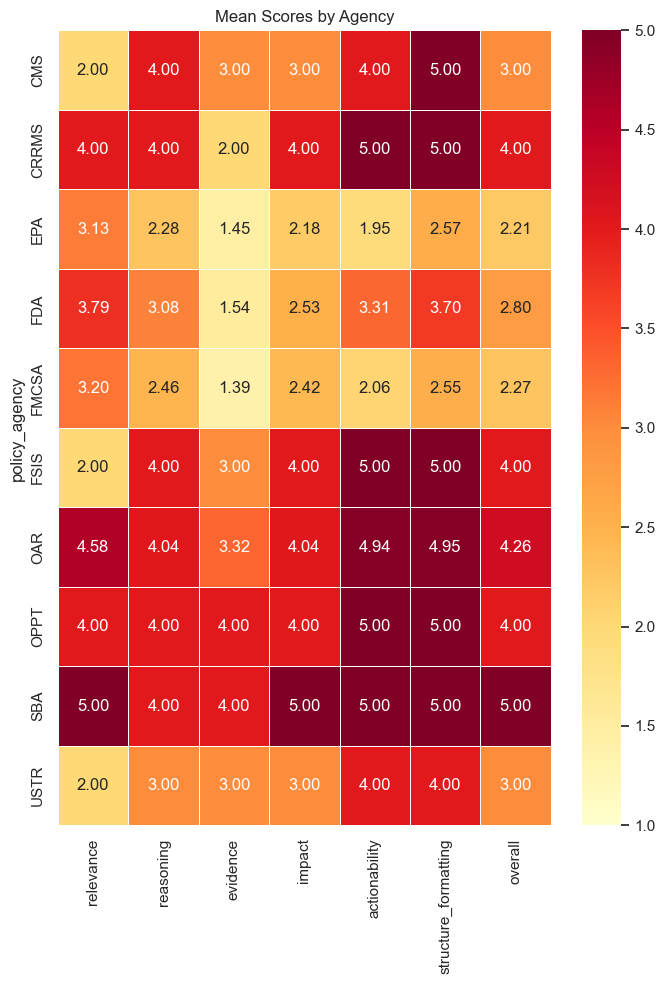

source_label,gemini,human,statt
policy_agency,,,
CMS,NaN,NaN,3.00
CRRMS,NaN,NaN,4.00
EPA,2.68,2.11,4.23
FDA,2.09,2.76,4.01
FMCSA,2.27,2.08,4.27
FSIS,NaN,NaN,4.00
OAR,NaN,NaN,4.26
OPPT,NaN,NaN,4.00
SBA,NaN,NaN,5.00


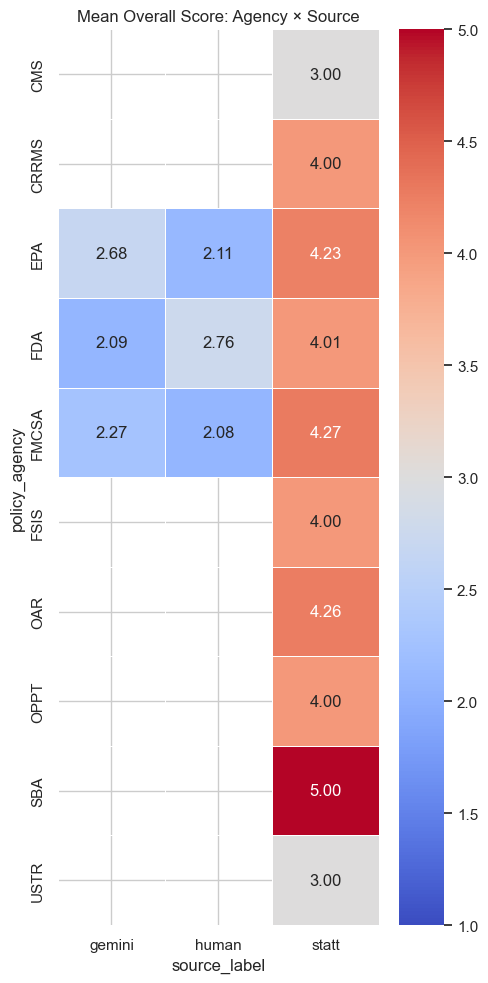

In [8]:
# ── Mean scores per agency ───────────────────────────────────────────────
summary_by_agency = df.groupby("policy_agency")[score_cols].mean().round(2)
display(summary_by_agency)

fig, ax = plt.subplots(figsize=(max(6, len(score_cols)), max(3, len(summary_by_agency))))
sns.heatmap(
    summary_by_agency,
    annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=1, vmax=5, linewidths=0.5, ax=ax,
    xticklabels=[c.replace("score_", "") for c in score_cols],
)
ax.set_title("Mean Scores by Agency")
plt.tight_layout()
plt.show()

# ── Mean overall score: agency × source ──────────────────────────────────
if "score_overall" in df.columns:
    pivot = df.pivot_table(
        values="score_overall",
        index="policy_agency",
        columns="source_label",
        aggfunc="mean",
    ).round(2)
    display(pivot)

    fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.5), max(3, len(pivot))))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="coolwarm",
        vmin=1, vmax=5, linewidths=0.5, ax=ax,
    )
    ax.set_title("Mean Overall Score: Agency × Source")
    plt.tight_layout()
    plt.show()

## Topic Modeling by Rationale (BERTopic)

Fits a separate topic model for each rationale field, for each source label. Helps identify systematic differences in how each source type discusses quality criteria.

Reproducibility: the UMAP step is seeded with a fixed `random_state` so topics are stable across runs.

In [9]:
MIN_DOCS = 10

CUSTOM_STOPWORDS = [
    "comment", "comments", "letter", "letters", "docket", "dockets",
    "epa", "fda", "fmcsa", "rule", "rulemaking", "proposed", "proposal",
    "agency", "agencies", "regulation", "regulations", "regulatory",
    "section", "sections", "public", "submit", "submitted", "submitting",
    "regarding", "related", "issue", "issues", "response", "responses",
]

def prep_texts(series):
    return [s for s in series.dropna().astype(str).tolist() if s.strip()]


def fit_topics(texts):
    if len(texts) < MIN_DOCS:
        return None
    combined_stopwords = list(ENGLISH_STOP_WORDS) + CUSTOM_STOPWORDS
    vectorizer = CountVectorizer(stop_words=combined_stopwords, min_df=2)
    umap_model = UMAP(random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=5)
    model = BERTopic(
        vectorizer_model=vectorizer,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        verbose=False,
    )
    model.fit(texts)
    return model


topic_models = {}
topic_summaries = {}

for col in rationale_cols:
    topic_summaries[col] = {}
    for label in labels:
        subset = df[df["source_label"] == label]
        texts = prep_texts(subset[col])
        model = fit_topics(texts)
        if model is None:
            topic_summaries[col][label] = pd.DataFrame({
                "note": [f"Not enough documents ({len(texts)})"],
            })
            continue
        topic_models[(col, label)] = model
        topic_summaries[col][label] = model.get_topic_info().head(10)

for col in rationale_cols:
    print(f"\n=== {col} ===")
    for label in labels:
        print(f"\n-- {label} --")
        display(topic_summaries[col][label])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
'[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

## Topic Modeling of LLM Evaluations

Analyze themes in the LLM-generated evaluation text (rationales and overall summaries) and compare `gemini`/`human`/`statt`.

In [ ]:
eval_cols = [c for c in df.columns if c.startswith("rationale_") or c == "overall_summary"]

def build_eval_text(row) -> str:
    parts = []
    for col in eval_cols:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())
    return "\n".join(parts)

eval_df = df.copy()
eval_df["eval_text"] = eval_df.apply(build_eval_text, axis=1)

eval_topic_summaries = {}

for label in labels:
    subset = eval_df[eval_df["source_label"] == label]
    texts = prep_texts(subset["eval_text"])
    model = fit_topics(texts)
    if model is None:
        eval_topic_summaries[label] = pd.DataFrame({
            "note": [f"Not enough documents ({len(texts)})"],
        })
        continue
    eval_topic_summaries[label] = model.get_topic_info().head(10)

print("\n=== LLM evaluation themes (all rationales + overall_summary) ===")
for label in labels:
    print(f"\n-- {label} --")
    display(eval_topic_summaries[label])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8,-1_relevant_fairly_reliability_general,"[relevant, fairly, reliability, general, impac...",[A relevant and professionally formatted comme...
1,0,107,0_safety_specific_evidence_operational,"[safety, specific, evidence, operational, gene...","[A concise, professionally formatted comment t..."
2,1,100,1_specific_does_concrete_evidence,"[specific, does, concrete, evidence, relevant,...",[The comment is directionally relevant to FDA ...
3,2,49,2_environmental_health_specific_relevant,"[environmental, health, specific, relevant, ev...",[The comment is broadly relevant to EPA public...
4,3,27,3_compliance_relevant_industry_plausible,"[compliance, relevant, industry, plausible, ev...",[A relevant and professionally presented comme...
5,4,9,4_agricultural_burdens_exemptions_compliance,"[agricultural, burdens, exemptions, compliance...",[A generally relevant but fairly thin public c...
6,5,8,5_small_business_compliance_smallbusiness,"[small, business, compliance, smallbusiness, b...",[A relevant EPA comment from a small plating b...
7,6,8,6_state_federal_implementation_specific,"[state, federal, implementation, specific, rel...",[A relevant and credible comment from a state ...



-- human --


,Topic,Count,Name,Representation,Representative_Docs
0,0,100,0_transparency_specific_does_evidence,"[transparency, specific, does, evidence, relev...",[This is a relevant public comment expressing ...
1,1,100,1_safety_concerns_clear_requests,"[safety, concerns, clear, requests, claims, or...",[A relevant and clearly organized comment that...
2,2,98,2_clear_specific_authority_state,"[clear, specific, authority, state, concrete, ...",[A focused and coherent opposition letter that...



-- statt --


,Topic,Count,Name,Representation,Representative_Docs
0,0,117,0_clear_claims_recommendations_impacts,"[clear, claims, recommendations, impacts, spec...",[A well-structured and highly relevant comment...
1,1,106,1_emergency_recommendations_clear_relief,"[emergency, recommendations, clear, relief, cl...",[A well-structured and highly relevant comment...
2,2,94,2_recommendations_claims_clear_reporting,"[recommendations, claims, clear, reporting, sp...",[A well-structured and highly relevant comment...


## Best and Worst Examples

Comments with the highest and lowest overall scores, across all sources.

In [ ]:
show_cols = [c for c in ["file", "display_name", "source_label", "policy_id",
                           "score_overall", "overall_summary"] if c in df.columns]

if "score_overall" in df.columns:
    scored = df.dropna(subset=["score_overall"])

    print("=== Top 5 comments (highest overall score) ===")
    display(scored.sort_values("score_overall", ascending=False).head(5)[show_cols])

    print("\n=== Bottom 5 comments (lowest overall score) ===")
    display(scored.sort_values("score_overall", ascending=True).head(5)[show_cols])

    # ── Top / bottom per source label ────────────────────────────────────
    for label in labels:
        subset = scored[scored["source_label"] == label]
        if subset.empty:
            continue
        print(f"\n=== [{label.upper()}] Top 3 ===")
        display(subset.sort_values("score_overall", ascending=False).head(3)[show_cols])
        print(f"\n=== [{label.upper()}] Bottom 3 ===")
        display(subset.sort_values("score_overall", ascending=True).head(3)[show_cols])

=== Top 5 comments (highest overall score) ===


,file,display_name,source_label,policy_id,score_overall,overall_summary
351,csv:fda_comments(Statt).csv:fda-comment-032,New York City Department of Health and Mental ...,statt,FDA,5.0,A well-structured and highly relevant public c...
191,csv:epa_comments(Statt).csv:epa-comment-082,American Public Health Association,statt,EPA,5.0,"A strong, professionally written comment that ..."
160,csv:epa_comments(Statt).csv:epa-comment-051,"Dr. Ana Diez Roux, Urban Health Researcher",statt,OAR-2025-0194,5.0,A polished and highly relevant comment letter ...
163,csv:epa_comments(Statt).csv:epa-comment-054,"David Kim, Urban Gardener and Teacher",statt,OAR-2025-0194,5.0,A strong and highly relevant comment letter th...
168,csv:epa_comments(Statt).csv:epa-comment-059,"Dr. Paul Anastas, Green Chemistry Pioneer",statt,OAR-2025-0194,5.0,"A strong, highly relevant comment letter that ..."



=== Bottom 5 comments (lowest overall score) ===


,file,display_name,source_label,policy_id,score_overall,overall_summary
814,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,"England Logistics, Inc.",human,FMCSA-2023-0257,1.0,The visible submission is only a placeholder d...
804,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,R & S trucking inc,human,FMCSA-2023-0257,1.0,The comment is relevant in a broad sense becau...
641,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,Stephens transport,human,FMCSA-2023-0257,1.0,The comment is only a brief statement of suppo...
817,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,NaN,human,EPA-HQ-OW-2025-2929,1.0,The submission is largely irrelevant to the do...
832,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,Sonu,human,FMCSA-2023-0257,1.0,The submission is effectively empty and does n...



=== [GEMINI] Top 3 ===


...

,file,display_name,source_label,policy_id,score_overall,overall_summary
853,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,PFL Logistics LLC,human,FMCSA-2023-0257,1.0,The visible comment is non-substantive and onl...
798,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,U.S Trucking,human,FMCSA-2023-0257,1.0,The comment is minimally relevant but too vagu...
804,/Users/norazhan/Desktop/MDI/Statt/LLM-eval/com...,R & S trucking inc,human,FMCSA-2023-0257,1.0,The comment is relevant in a broad sense becau...



=== [STATT] Top 3 ===


,file,display_name,source_label,policy_id,score_overall,overall_summary
109,csv:epa_comments(Statt).csv:epa-comment-000,American Chemistry Council,statt,OAR-2025-0194,5.0,A well-structured and highly relevant industry...
168,csv:epa_comments(Statt).csv:epa-comment-059,"Dr. Paul Anastas, Green Chemistry Pioneer",statt,OAR-2025-0194,5.0,"A strong, highly relevant comment letter that ..."
533,csv:fmcsa_comments(Statt).csv:fmcsa-comment-005,Rodriguez Family Trucking,statt,FMCSA-2025-0124,5.0,A strong and highly relevant comment letter th...



=== [STATT] Bottom 3 ===


,file,display_name,source_label,policy_id,score_overall,overall_summary
398,csv:fda_comments(Statt).csv:fda-comment-079,"Michael Torres, Restaurant Owner",statt,FDA,1.0,The comment is non-substantive and does not en...
369,csv:fda_comments(Statt).csv:fda-comment-050,National Cattlemen's Beef Association,statt,USTR-2024-0015,3.0,A well-structured and actionable industry comm...
548,csv:fmcsa_comments(Statt).csv:fmcsa-comment-020,National Motorists Association,statt,FMCSA-2025-0124,3.0,This is a well-structured and clearly written ...
